In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as st
import scipy.optimize as opt
# Cargar datos
gal_0 = pd.read_csv('/mnt/sda2/extragalactica/2_practico/pr2_shulypuddu.csv')
head= 'ra,dec,z,c_par,fracDeV_r,velDisp,abs_model_mag_u,abs_model_mag_g,abs_model_mag_r,abs_model_mag_i,abs_model_mag_z,abs_petro_mag_u,abs_petro_mag_g,abs_petro_mag_r,abs_petro_mag_i,abs_petro_mag_z,color_u_r,color_g_r,mu_sup,petroR50_r,petroR90_r'
df0 = pd.read_csv('/mnt/sda2/extragalactica/2_practico/galaxias_finales.csv', names=head.split(','), skiprows=1)
bar_color="#7166D1"
edge_color= "#695ED1"
linea_color='tomato'

galaxias_brillante = df0[df0['abs_model_mag_r'] > -15]
#esta galaxia no se xq quedo tan FEA, asique la filtro
df = df0[df0['abs_model_mag_r'] < -15]
tempranas = df[df['c_par'] >= 2.5]
tardias = df[df['c_par'] < 2.5]

bulge = df[df['fracDeV_r'] >= 0.8]
disco = df[df['fracDeV_r']<= 0.2]




NameError: name 'x_cruce' is not defined

In [12]:
df.head()

,ra,dec,z,c_par,fracDeV_r,velDisp,abs_model_mag_u,abs_model_mag_g,abs_model_mag_r,abs_model_mag_i,...,abs_petro_mag_u,abs_petro_mag_g,abs_petro_mag_r,abs_petro_mag_i,abs_petro_mag_z,color_u_r,color_g_r,mu_sup,petroR50_r,petroR90_r
0,248.427338,40.153099,0.029141,3.313087,1.000000,120.217003,-18.081985,-19.792364,-20.566236,-20.911688,...,-18.114418,-19.751654,-20.515257,-20.859497,-21.099255,2.484251,0.773872,19.543352,1.816034,6.016678
1,246.718796,40.970314,0.029176,2.386080,0.430332,23.562990,-17.193432,-18.272331,-18.607775,-18.798756,...,-16.602791,-17.723532,-17.989046,-17.940647,-18.180756,1.414343,0.335443,22.887016,2.654387,6.333578
2,179.244446,61.456379,0.042445,2.556281,0.000000,42.245541,-18.178293,-19.584330,-20.246607,-20.587896,...,-18.299414,-19.633509,-20.228508,-20.469255,-20.720722,2.068314,0.662277,21.683024,4.068568,10.400403
3,246.704376,42.678925,0.030449,2.392693,0.385215,74.192261,-17.313629,-18.892509,-19.668669,-20.021475,...,-17.116110,-18.930010,-19.740999,-20.029165,-20.327076,2.355040,0.776159,21.168137,2.675173,6.400869
4,239.459000,48.609646,0.020696,1.802537,0.000000,0.000000,-16.646736,-17.962826,-18.573967,-18.822937,...,-16.573187,-17.829836,-18.475717,-18.679157,-18.886627,1.927231,0.611141,22.258551,2.489359,4.487163


In [3]:
ra = gal_0['ra']
dec = gal_0['dec']
z = gal_0['z']
r_corregido= gal_0['petroMag_r']-gal_0['extinction_r']


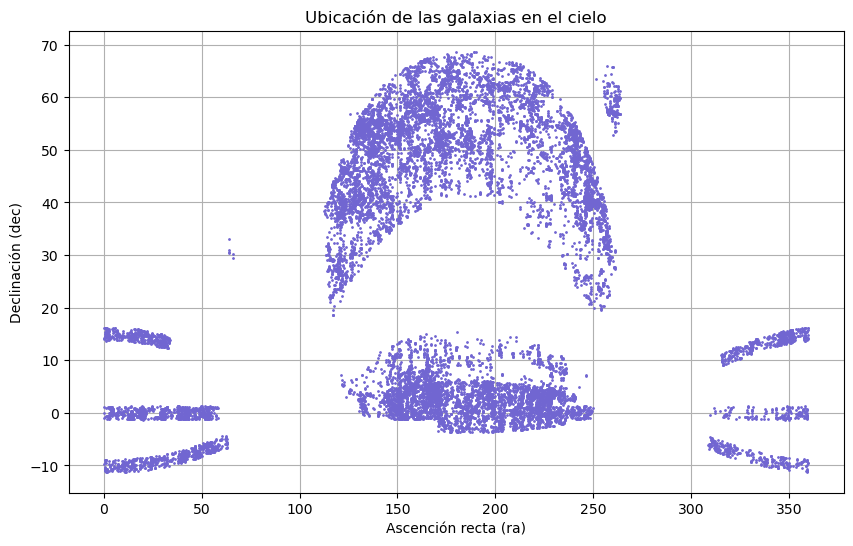

In [4]:
plt.figure(figsize=(10, 6))
plt.plot(ra, dec, 'o', markersize=1, color=bar_color)
plt.xlabel("Ascención recta (ra)")
plt.ylabel("Declinación (dec)")
plt.title("Ubicación de las galaxias en el cielo")
plt.grid(True)
plt.savefig('/mnt/sda2/extragalactica/2_practico/imagenes/gal_in_sky.png', dpi=300,bbox_inches='tight')

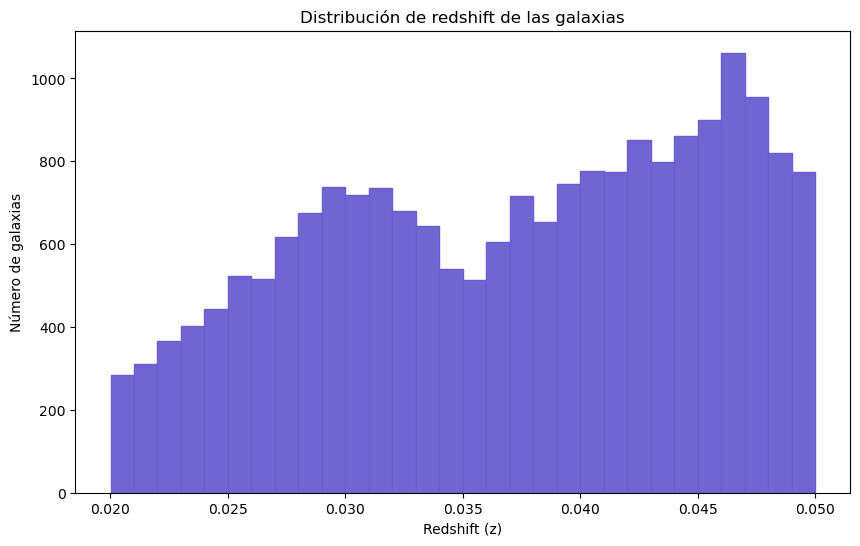

In [4]:
plt.figure(figsize=(10,6))
plt.hist(z, bins=30, edgecolor=edge_color,facecolor=bar_color)
plt.xlabel("Redshift (z)")
plt.ylabel("Número de galaxias")
plt.title("Distribución de redshift de las galaxias")
plt.savefig('/mnt/sda2/extragalactica/2_practico/imagenes/gal_z.png', dpi=300,bbox_inches='tight')


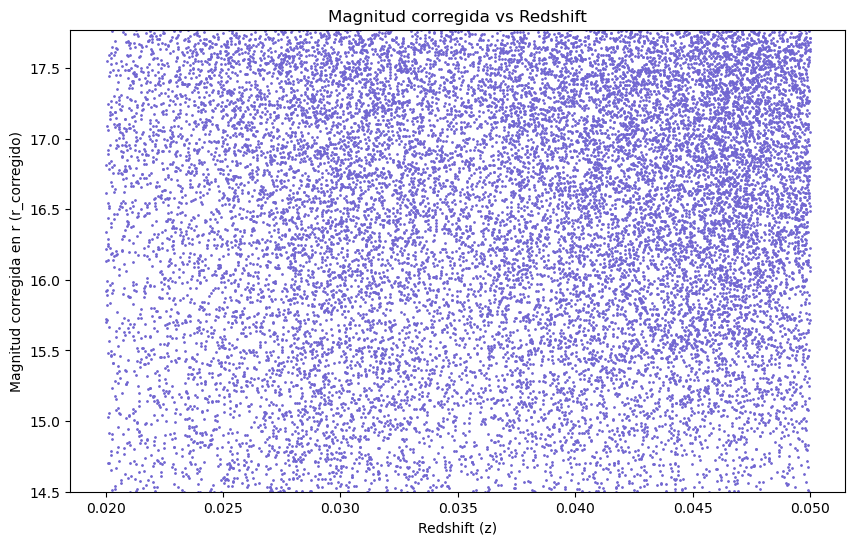

In [5]:
plt.figure(figsize=(10,6))
plt.scatter(z, r_corregido, s=1, color=bar_color)
plt.ylim(14.5,17.77)
plt.xlabel("Redshift (z)")
plt.ylabel("Magnitud corregida en r (r_corregido)")
plt.title("Magnitud corregida vs Redshift")
plt.savefig('/mnt/sda2/extragalactica/2_practico/imagenes/mag_vs_z.png', dpi=300,bbox_inches='tight')

In [5]:
color_u_r = df['color_u_r'].dropna()

# Definir la función suma de dos gaussianas
def doble_gaussiana(x, amp1, mu1, sigma1, amp2, mu2, sigma2):
    return (amp1 * np.exp(-(x - mu1)**2 / (2 * sigma1**2)) +
            amp2 * np.exp(-(x - mu2)**2 / (2 * sigma2**2)))

def gauss(x,amp,mu,sigma):
    return amp * np.exp(-(x - mu)**2 / (2 * sigma**2))

# Obtener histograma (cuentas y bordes)

cuentas, bordes = np.histogram(color_u_r, bins=1000,density=True)
centros = (bordes[:-1] + bordes[1:]) / 2

# Estimaciones iniciales para los parámetros
p0 = [1, color_u_r.mean()-0.5, color_u_r.std()/2, 1, color_u_r.mean()+0.5, color_u_r.std()/2]

# Ajuste
params, cov = opt.curve_fit(doble_gaussiana, centros, cuentas, p0=p0)

x_fit = np.linspace(color_u_r.min(), color_u_r.max(), 200)
x1_fit = np.linspace(color_u_r.min(), 3, 200)
x2_fit = np.linspace( 1,color_u_r.max(), 200)
g_azul= gauss(x1_fit,params[0],params[1],params[2])
g_rojo= gauss(x2_fit,params[3],params[4],params[5])

def diferencia(x):
    return gauss(x,params[0],params[1],params[2]) - gauss(x,params[3],params[4],params[5])
x_inicial= (params[4]+params[1])/2
x_cruce = opt.fsolve(diferencia, x_inicial)[0]

rojo = df[df['color_u_r'] > x_cruce]
azul = df[df['color_u_r'] < x_cruce]


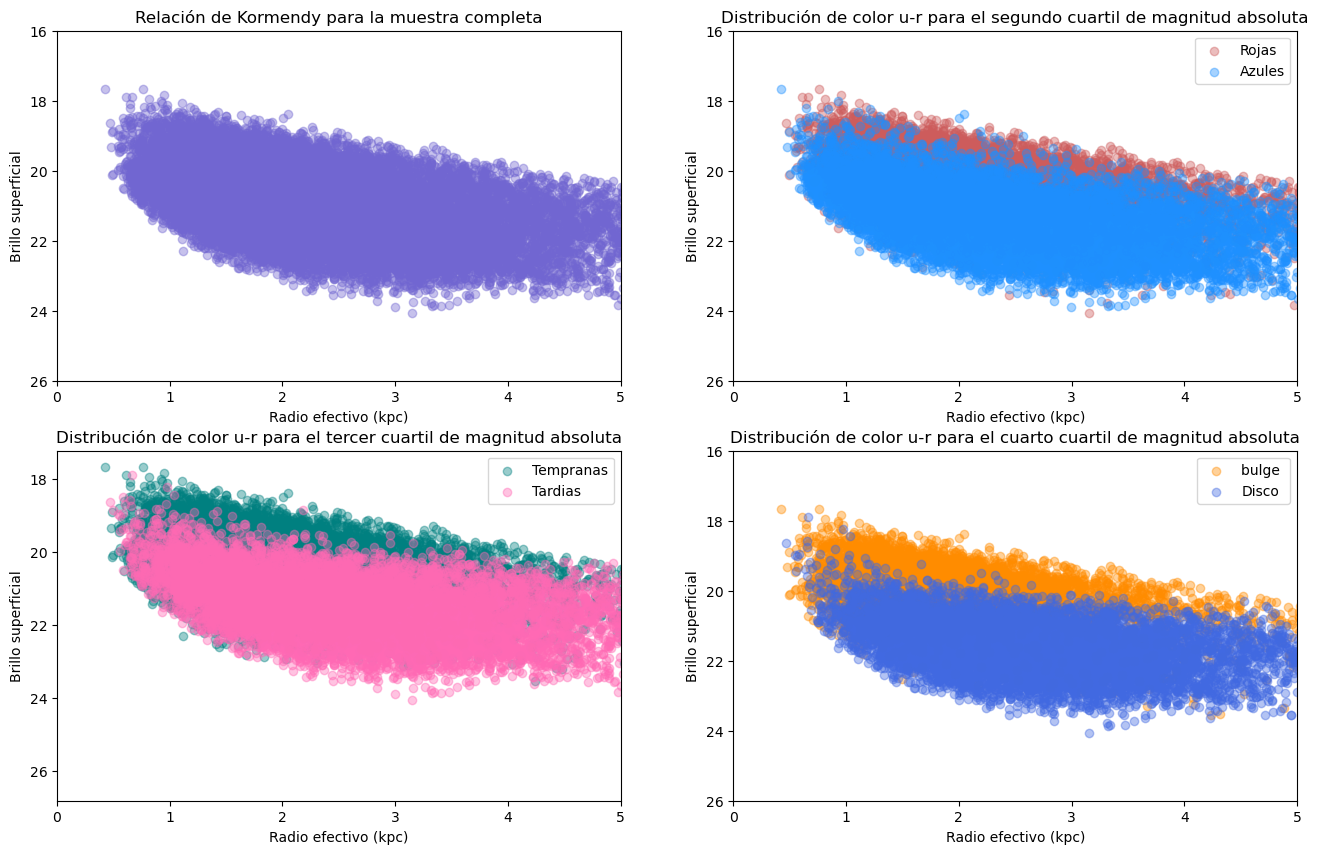

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10)) # 2 filas, 2 columnas

axs[0, 0].scatter(df['petroR50_r'],df['mu_sup'],color=bar_color,alpha=0.4)
axs[0, 0].set_title('Relación de Kormendy para la muestra completa')
axs[0, 0].set_xlabel('Radio efectivo (kpc)')
axs[0, 0].set_ylabel('Brillo superficial')
axs[0, 0].set_xlim(0,5)
axs[0, 0].set_ylim(16,26)
axs[0, 0].invert_yaxis()  


axs[0, 1].scatter(rojo['petroR50_r'],rojo['mu_sup'],color='indianred',alpha=0.4,label=f'Rojas')
axs[0, 1].scatter(azul['petroR50_r'],azul['mu_sup'],color='dodgerblue',alpha=0.4,label=f'Azules')
axs[0, 1].set_title('Distribución de color u-r para el segundo cuartil de magnitud absoluta')
axs[0, 1].set_xlabel('Radio efectivo (kpc)')
axs[0, 1].set_ylabel('Brillo superficial')
axs[0, 1].set_xlim(0,5)
axs[0, 1].set_ylim(16,26)
axs[0, 1].invert_yaxis()
axs[0, 1].legend()

axs[1, 0].scatter(tempranas['petroR50_r'],tempranas['mu_sup'],color='teal',alpha=0.4,label=f'Tempranas')
axs[1, 0].scatter(tardias['petroR50_r'],tardias['mu_sup'],color='hotpink',alpha=0.4,label=f'Tardias')
axs[1, 0].set_title('Distribución de color u-r para el tercer cuartil de magnitud absoluta')
axs[1, 0].set_xlabel('Radio efectivo (kpc)')
axs[1, 0].set_ylabel('Brillo superficial')
axs[1, 0].set_xlim(0,5)
axs[1, 0].invert_yaxis()
axs[1, 0].legend()

axs[1, 1].scatter(bulge['petroR50_r'],bulge['mu_sup'],color='darkorange',alpha=0.4,label=f'bulge ')
axs[1, 1].scatter(disco['petroR50_r'],disco['mu_sup'],color='royalblue',alpha=0.4,label=f'Disco')
axs[1, 1].set_title('Distribución de color u-r para el cuarto cuartil de magnitud absoluta')
axs[1, 1].set_xlabel('Radio efectivo (kpc)')
axs[1, 1].set_ylabel('Brillo superficial')
axs[1, 1].set_xlim(0,5)
axs[1, 1].invert_yaxis()
axs[1, 1].legend()

plt.savefig('/mnt/sda2/extragalactica/2_practico/imagenes/color_vs_mag_cuartiles.png', dpi=300,bbox_inches='tight')



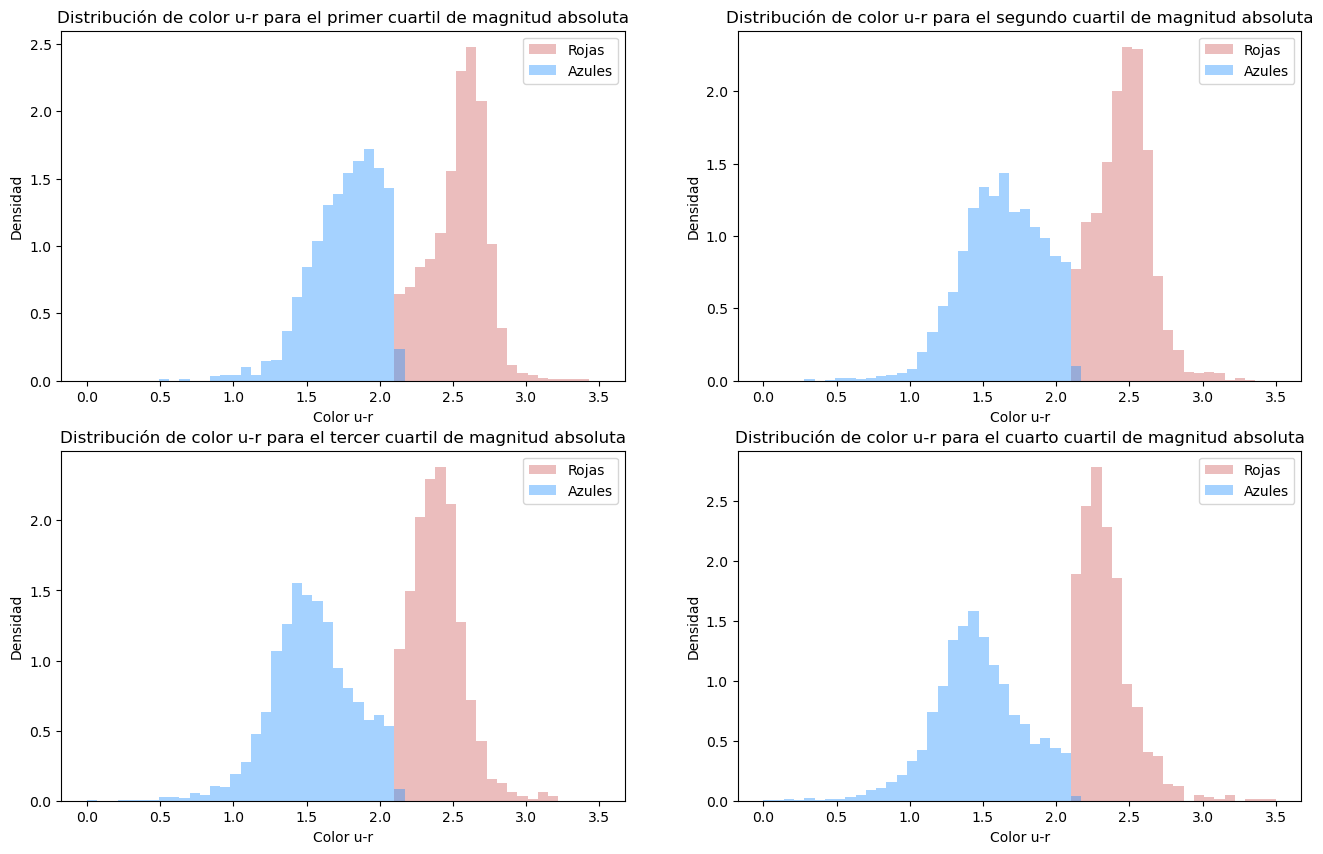

In [6]:
m_25=np.percentile(df['abs_petro_mag_r'],25)
mask_25=df['abs_petro_mag_r']<=m_25
m_50=np.percentile(df['abs_petro_mag_r'],50)
mask_50=(df['abs_petro_mag_r']<=m_50) & (df['abs_petro_mag_r']>m_25)
m_75=np.percentile(df['abs_petro_mag_r'],75)
mask_75=(df['abs_petro_mag_r']<=m_75) & (df['abs_petro_mag_r']>m_50)
mask_100=df['abs_petro_mag_r']>m_75
bin=50
fig, axs = plt.subplots(2, 2, figsize=(16, 10)) # 2 filas, 2 columnas

axs[0, 0].hist(rojo['color_u_r'][mask_25],range=[0.0,3.5],bins=bin,density=True,color='indianred',alpha=0.4,label=f'Rojas')
axs[0, 0].hist(azul['color_u_r'][mask_25],range=[0.0,3.5],bins=bin,density=True,color='dodgerblue',alpha=0.4,label=f'Azules')
axs[0, 0].set_title('Distribución de color u-r para el primer cuartil de magnitud absoluta')
axs[0, 0].set_xlabel('Color u-r')
axs[0, 0].set_ylabel('Densidad')
axs[0, 0].legend()
axs[0, 1].hist(rojo['color_u_r'][mask_50],range=[0.0,3.5],bins=bin,density=True,color='indianred',alpha=0.4,label=f'Rojas')
axs[0, 1].hist(azul['color_u_r'][mask_50],range=[0.0,3.5],bins=bin,density=True,color='dodgerblue',alpha=0.4,label=f'Azules')
axs[0, 1].set_title('Distribución de color u-r para el segundo cuartil de magnitud absoluta')
axs[0, 1].set_xlabel('Color u-r')
axs[0, 1].set_ylabel('Densidad')
axs[0, 1].legend()
axs[1, 0].hist(rojo['color_u_r'][mask_75],range=[0.0,3.5],bins=bin,density=True,color='indianred',alpha=0.4,label=f'Rojas')
axs[1, 0].hist(azul['color_u_r'][mask_75],range=[0.0,3.5],bins=bin,density=True,color='dodgerblue',alpha=0.4,label=f'Azules')
axs[1, 0].set_title('Distribución de color u-r para el tercer cuartil de magnitud absoluta')
axs[1, 0].set_xlabel('Color u-r')
axs[1, 0].set_ylabel('Densidad')
axs[1, 0].legend()
axs[1, 1].hist(rojo['color_u_r'][mask_100],range=[0.0,3.5],bins=bin,density=True,color='indianred',alpha=0.4,label=f'Rojas')
axs[1, 1].hist(azul['color_u_r'][mask_100],range=[0.0,3.5],bins=bin,density=True,color='dodgerblue',alpha=0.4,label=f'Azules')
axs[1, 1].set_title('Distribución de color u-r para el cuarto cuartil de magnitud absoluta')
axs[1, 1].set_xlabel('Color u-r')
axs[1, 1].set_ylabel('Densidad')
axs[1, 1].legend()
plt.savefig('/mnt/sda2/extragalactica/2_practico/imagenes/color_vs_mag_cuartiles.pdf', dpi=300,bbox_inches='tight')



In [12]:
hist25, borde25 = np.histogram(df['color_u_r'][mask_25], bins='auto', density=True,range=[0.0,3.5])
hist50, borde50 = np.histogram(df['color_u_r'][mask_50], bins='auto', density=True,range=[0.0,3.5])
hist75, borde75 = np.histogram(df['color_u_r'][mask_75], bins='auto', density=True,range=[0.0,3.5])
hist100, borde100 = np.histogram(df['color_u_r'][mask_100], bins='auto', density=True,range=[0.0,3.5])

centro25 = (borde25[:-1] + borde25[1:]) / 2
centro50 = (borde50[:-1] + borde50[1:]) / 2
centro75 = (borde75[:-1] + borde75[1:]) / 2
centro100 = (borde100[:-1] + borde100[1:])/2

# Estimaciones iniciales para los parámetros
p0 = [1, df['color_u_r'].mean()-0.5, df['color_u_r'].std()/2, 1, df['color_u_r'].mean()+0.5, df['color_u_r'].std()/2]

# Ajuste
par25, cov25 = opt.curve_fit(doble_gaussiana, centro25, hist25, p0=p0)
par50, cov50 = opt.curve_fit(doble_gaussiana, centro50, hist50, p0=p0)
par75, cov75 = opt.curve_fit(doble_gaussiana, centro75, hist75, p0=p0)
par100, cov100 = opt.curve_fit(doble_gaussiana, centro100, hist100, p0=p0)

In [11]:
medio25=(df['abs_petro_mag_r'][mask_25].mean())
medio50=(df['abs_petro_mag_r'][mask_50].mean())
medio75=(df['abs_petro_mag_r'][mask_75].mean())
medio100=(df['abs_petro_mag_r'][mask_100].mean())



In [10]:
M_a25,mu_25a,sig_25a, M_r25,mu_25r,sig_25r = par25
M_a50,mu_50a,sig_50a, M_r50,mu_50r,sig_50r = par50
M_a75,mu_75a,sig_75a, M_r75,mu_75r,sig_75r = par75
M_a100,mu_100a,sig_100a, M_r100,mu_100r,sig_100r = par100

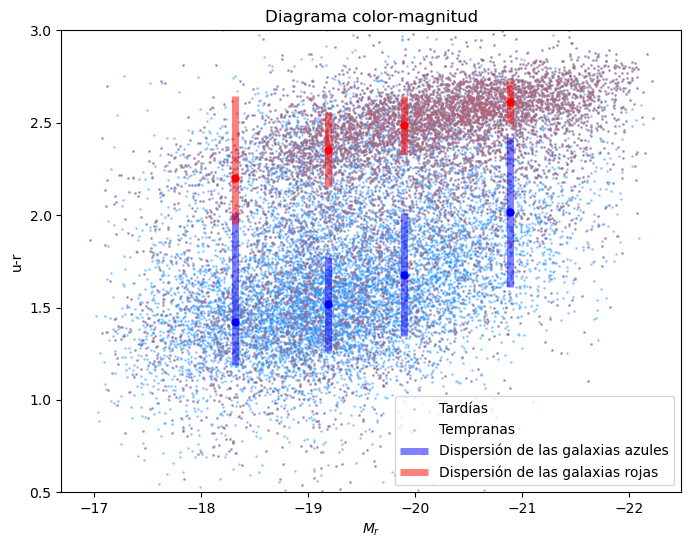

In [13]:
mas_c=df['c_par']>2.5

plt.figure(figsize=(8,6))
plt.scatter(df['abs_petro_mag_r'], df['color_u_r'], alpha=0.35,color='dodgerblue', label='Tardías',s=1)
plt.scatter(df['abs_petro_mag_r'][mas_c], df['color_u_r'][mas_c],alpha=0.35, color='indianred', label='Tempranas',s=1)
plt.vlines(medio25,mu_25a-sig_25a,mu_25a+sig_25a,'b','solid',alpha=0.5,linewidth=5,label='Dispersión de las galaxias azules')
plt.vlines(medio50,mu_50a-sig_50a,mu_50a+sig_50a,'b','solid',alpha=0.5,linewidth=5)
plt.vlines(medio75,mu_75a-sig_75a,mu_75a+sig_75a,'b','solid',alpha=0.5,linewidth=5)
plt.vlines(medio100,mu_100a-sig_100a,mu_50a+sig_50a,'b','solid',alpha=0.5,linewidth=5)

plt.vlines(medio25,mu_25r-sig_25r,mu_25r+sig_25r,'r','solid',alpha=0.5,linewidth=5,label='Dispersión de las galaxias rojas')
plt.vlines(medio50,mu_50r-sig_50r,mu_50r+sig_50r,'r','solid',alpha=0.5,linewidth=5)
plt.vlines(medio75,mu_75r-sig_75r,mu_75r+sig_75r,'r','solid',alpha=0.5,linewidth=5)
plt.vlines(medio100,mu_100r-sig_100r,mu_50r+sig_50r,'r','solid',alpha=0.5,linewidth=5)

plt.scatter(medio25, mu_25r, s=25, color='r')
plt.scatter(medio50, mu_50r, s=25, color='r')
plt.scatter(medio75, mu_75r, s=25, color='r')
plt.scatter(medio100, mu_100r, s=25, color='r')

plt.scatter(medio25, mu_25a, s=25, color='b')
plt.scatter(medio50, mu_50a, s=25, color='b')
plt.scatter(medio75, mu_75a, s=25, color='b')
plt.scatter(medio100, mu_100a, s=25, color='b')

plt.xlabel('$M_r$')
plt.ylabel('u-r')
plt.gca().invert_xaxis()
plt.ylim((0.5,3))

plt.title('Diagrama color-magnitud')
plt.legend()
plt.savefig('/mnt/sda2/extragalactica/2_practico/imagenes/diagrama_color_magnitud_dispersion.png', dpi=300,bbox_inches='tight')
plt.show()

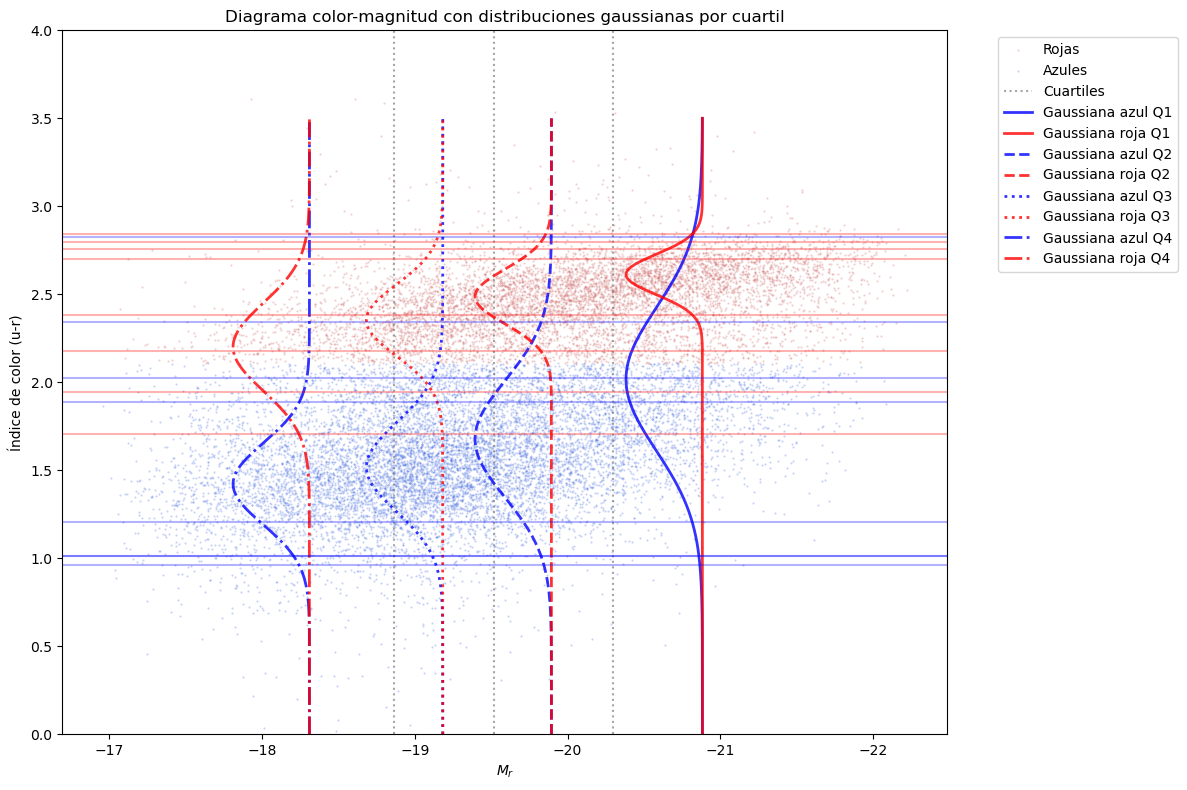

In [25]:
plt.figure(figsize=(12,8))

# Scatter plot de los datos
plt.scatter(rojo['abs_petro_mag_r'],rojo['color_u_r'],  marker='.',color='indianred',alpha=0.3,label='Rojas', s=1)
plt.scatter(azul['abs_petro_mag_r'],azul['color_u_r'],marker='.',color='royalblue',alpha=0.3,label='Azules', s=1)

# Líneas de cuartiles
plt.axvline(m_25, color='gray', linestyle=':', alpha=0.7, label='Cuartiles')
plt.axvline(m_50, color='gray', linestyle=':', alpha=0.7)
plt.axvline(m_75, color='gray', linestyle=':', alpha=0.7)

# Valores de magnitud para cada cuartil (centros)
mag_25 = df['abs_petro_mag_r'][mask_25].mean()
mag_50 = df['abs_petro_mag_r'][mask_50].mean()
mag_75 = df['abs_petro_mag_r'][mask_75].mean()
mag_100 = df['abs_petro_mag_r'][mask_100].mean()

# Graficar gaussianas para cada cuartil
# Cuartil 1 (25%)
color_range = np.linspace(0, 3.5, 200)
gauss1_azul = gauss(color_range, par25[0], par25[1], par25[2])
gauss1_rojo = gauss(color_range, par25[3], par25[4], par25[5])

# Normalizar y escalar para visualización
scale_factor = 0.5  # Factor de escala para las gaussianas
gauss1_azul_norm = gauss1_azul / gauss1_azul.max() * scale_factor + mag_25
gauss1_rojo_norm = gauss1_rojo / gauss1_rojo.max() * scale_factor + mag_25

plt.plot(gauss1_azul_norm, color_range, 'b-', linewidth=2, alpha=0.8, label='Gaussiana azul Q1')
plt.plot(gauss1_rojo_norm, color_range, 'r-', linewidth=2, alpha=0.8, label='Gaussiana roja Q1')

# Cuartil 2 (50%)
gauss2_azul = gauss(color_range, par50[0], par50[1], par50[2])
gauss2_rojo = gauss(color_range, par50[3], par50[4], par50[5])
gauss2_azul_norm = gauss2_azul / gauss2_azul.max() * scale_factor + mag_50
gauss2_rojo_norm = gauss2_rojo / gauss2_rojo.max() * scale_factor + mag_50

plt.plot(gauss2_azul_norm, color_range, 'b--', linewidth=2, alpha=0.8, label='Gaussiana azul Q2')
plt.plot(gauss2_rojo_norm, color_range, 'r--', linewidth=2, alpha=0.8, label='Gaussiana roja Q2')

# Cuartil 3 (75%)
gauss3_azul = gauss(color_range, par75[0], par75[1], par75[2])
gauss3_rojo = gauss(color_range, par75[3], par75[4], par75[5])
gauss3_azul_norm = gauss3_azul / gauss3_azul.max() * scale_factor + mag_75
gauss3_rojo_norm = gauss3_rojo / gauss3_rojo.max() * scale_factor + mag_75

plt.plot(gauss3_azul_norm, color_range, 'b:', linewidth=2, alpha=0.8, label='Gaussiana azul Q3')
plt.plot(gauss3_rojo_norm, color_range, 'r:', linewidth=2, alpha=0.8, label='Gaussiana roja Q3')

# Cuartil 4 (100%)
gauss4_azul = gauss(color_range, par100[0], par100[1], par100[2])
gauss4_rojo = gauss(color_range, par100[3], par100[4], par100[5])
gauss4_azul_norm = gauss4_azul / gauss4_azul.max() * scale_factor + mag_100
gauss4_rojo_norm = gauss4_rojo / gauss4_rojo.max() * scale_factor + mag_100

plt.plot(gauss4_azul_norm, color_range, 'b-.', linewidth=2, alpha=0.8, label='Gaussiana azul Q4')
plt.plot(gauss4_rojo_norm, color_range, 'r-.', linewidth=2, alpha=0.8, label='Gaussiana roja Q4')

# Agregar líneas para μ ± 2σ de cada gaussiana
for i, (params, mag_center, label) in enumerate([(par25, mag_25, 'Q1'), (par50, mag_50, 'Q2'), 
                                                  (par75, mag_75, 'Q3'), (par100, mag_100, 'Q4')]):
    # Gaussiana azul
    mu_azul, sigma_azul = params[1], params[2]
    plt.axhline(mu_azul - 2*sigma_azul, color='blue', alpha=0.3, linestyle='-')
    plt.axhline(mu_azul + 2*sigma_azul, color='blue', alpha=0.3, linestyle='-')
    
    # Gaussiana roja
    mu_rojo, sigma_rojo = params[4], params[5]
    plt.axhline(mu_rojo - 2*sigma_rojo, color='red', alpha=0.3, linestyle='-')
    plt.axhline(mu_rojo + 2*sigma_rojo, color='red', alpha=0.3, linestyle='-')

plt.ylim(0,4)
plt.ylabel('Índice de color (u-r)')
plt.xlabel('$M_r$')
plt.title('Diagrama color-magnitud con distribuciones gaussianas por cuartil')
plt.gca().invert_xaxis()
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('/mnt/sda2/extragalactica/2_practico/imagenes/dcm_ur_gaussianas.png', dpi=300, bbox_inches='tight')
plt.show()